# GHZ-Zustand und Quantum Fourier Transform


1. Vorbereitung eines Drei-Qubit-GHZ-Zustands
2. Vorbereitung des Zustands `|1000>` und anschließende Quantum Fourier Transform (QFT)

## 1. GHZ-State Preparation

Der Drei-Qubit-GHZ-Zustand ist

`|GHZ> = (|000> + |111>) / sqrt(2)`

Dazu wenden wir zuerst ein Hadamard-Gatter auf `q0` an. Die beiden CNOT-Gatter
übertragen die Superposition anschließend auf `q1` und `q2`.

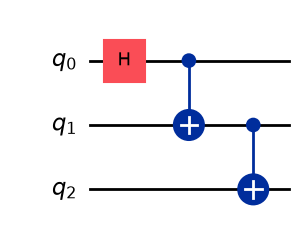

In [1]:
from qiskit import QuantumCircuit

ghz_circuit = QuantumCircuit(3)
ghz_circuit.h(0)
ghz_circuit.cx(0, 1)
ghz_circuit.cx(1, 2)

ghz_circuit.draw(output="mpl")

Die Schaltung besteht aus einem Hadamard-Gatter und zwei kontrollierten-X-Gattern.
Die letzte Codezeile zeigt den Circuit als grafische Darstellung im Notebook.

## 2. Vier Qubits und die QFT

Zuerst erzeugen wir `|1000>` mit vier Qubits. Wegen der Reihenfolge `|q3 q2 q1 q0>`
muss dafür `q3` invertiert werden. Danach fügen wir die eingebaute `QFTGate` aus
Qiskits Circuit Library hinzu.

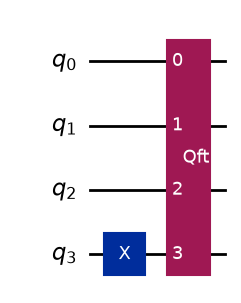

In [2]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import QFTGate

qft_circuit = QuantumCircuit(4)
qft_circuit.x(3)
qft_circuit.append(QFTGate(4), range(4))

qft_circuit.draw(output="mpl")

## 3. Transpilation auf `u` und `cx`

`transpile` zerlegt die QFT in eine vorgegebene Menge elementarer Gatter.
Mit `basis_gates=["u", "cx"]` erlauben wir nur beliebige Einzel-Qubit-Gatter
(`u`) und kontrollierte-X-Gatter (`cx`).

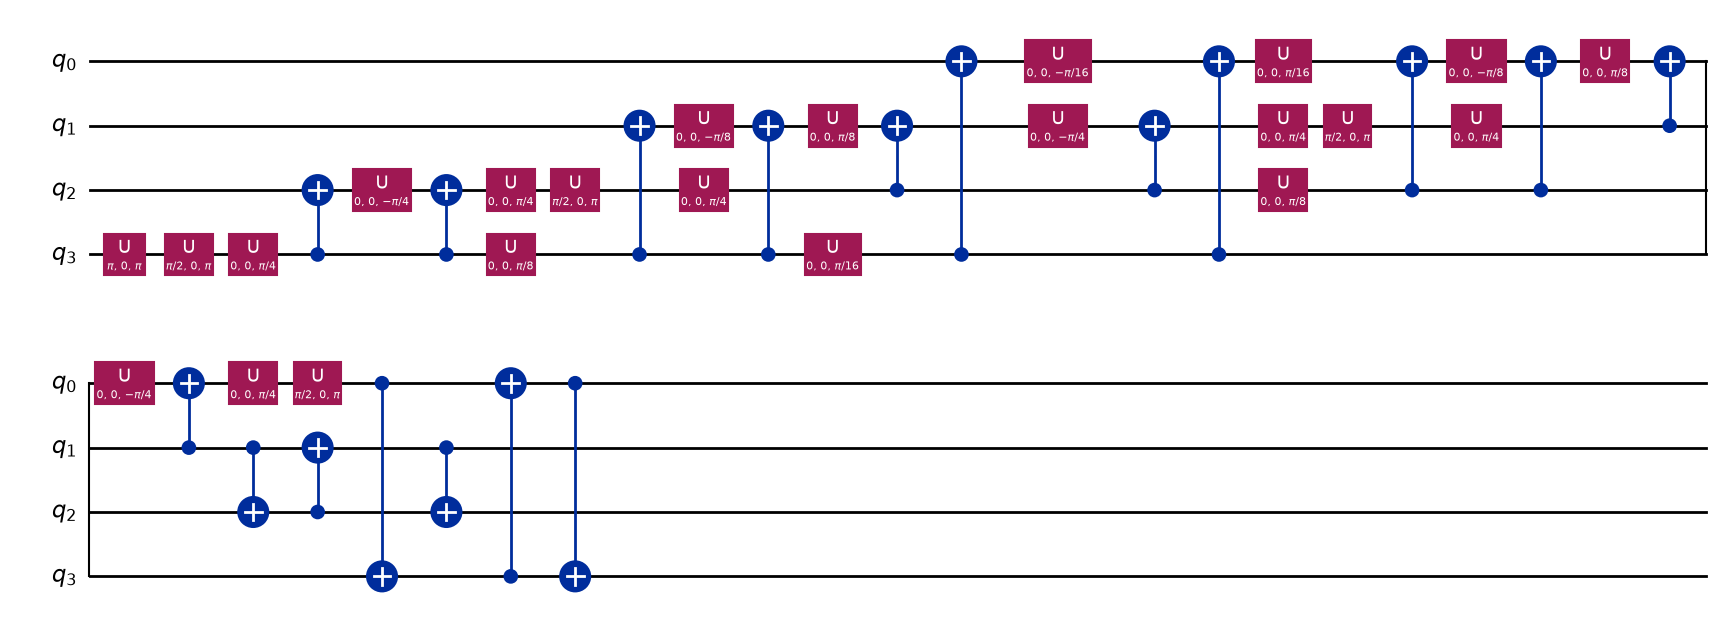

In [9]:
from qiskit import transpile

transpiled_qft = transpile(
    qft_circuit,
    basis_gates=["u", "cx"],
    optimization_level=0,
)
transpiled_qft.draw(output="mpl")


Die letzte Ausgabe ist die verlangte visualisierte, transpiliierte Schaltung.
Alle ursprünglichen QFT-Gatter wurden dabei in `u`- und `cx`-Gatter übersetzt.

## 4. Messungen mit dem AerSimulator

Für die Messung erstellen wir eine Kopie des transpilierten Circuits und fügen Messungen für alle vier Qubits hinzu. Der `AerSimulator` führt den Circuit mit vielen Wiederholungen (`shots`) aus. Das Histogramm zeigt, wie oft jedes Messergebnis aufgetreten ist.


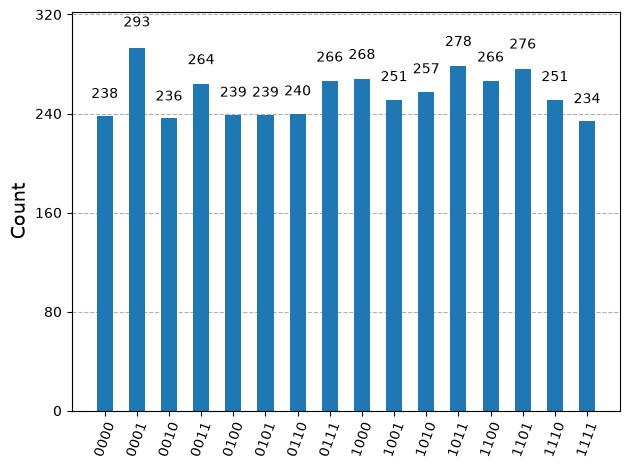

In [10]:
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

measured_qft = transpiled_qft.copy()
measured_qft.measure_all()

simulator = AerSimulator()
shots = 4096
result = simulator.run(measured_qft, shots=shots).result()
counts = result.get_counts()

plot_histogram(counts)


## 5. Exakter Statevector und analytischer Vergleich

Für den Statevector verwenden wir eine zweite Kopie des transpilierten Circuits ohne Messungen. Für die QFT gilt allgemein

`QFT|x> = 1/sqrt(16) * sum_y exp(2*pi*i*x*y/16) |y>`.

Für `|1000>` ist `x = 8`. Deshalb sind alle Amplituden gleich groß und ihre Vorzeichen wechseln sich ab. Die Transpilation kann zusätzlich eine globale Phase erzeugen; diese wird vor dem Vergleich entfernt.


In [8]:
import numpy as np
from qiskit.quantum_info import Statevector

statevector_circuit = transpiled_qft.copy()
exact_statevector = Statevector.from_instruction(statevector_circuit)
actual_amplitudes = np.asarray(exact_statevector.data)

num_states = 2**4
input_integer = 8
analytical_amplitudes = np.array(
    [np.exp(2j * np.pi * input_integer * output_integer / num_states) / np.sqrt(num_states)
     for output_integer in range(num_states)]
)

# Remove a possible global phase introduced during transpilation.
phase = np.vdot(analytical_amplitudes, actual_amplitudes)
phase /= abs(phase)
aligned_amplitudes = actual_amplitudes / phase

comparison = np.column_stack((analytical_amplitudes, aligned_amplitudes))
for state_index, (analytical, actual) in enumerate(comparison):
    print(
        f"|{state_index:04b}>: "
        f"analytisch = {analytical.real:+.3f}{analytical.imag:+.3f}j, "
        f"Statevector = {actual.real:+.3f}{actual.imag:+.3f}j"
    )

print("Amplituden stimmen überein:", np.allclose(analytical_amplitudes, aligned_amplitudes))


|0000>: analytisch = +0.250+0.000j, Statevector = +0.250-0.000j
|0001>: analytisch = -0.250+0.000j, Statevector = -0.250+0.000j
|0010>: analytisch = +0.250-0.000j, Statevector = +0.250-0.000j
|0011>: analytisch = -0.250+0.000j, Statevector = -0.250+0.000j
|0100>: analytisch = +0.250-0.000j, Statevector = +0.250-0.000j
|0101>: analytisch = -0.250+0.000j, Statevector = -0.250+0.000j
|0110>: analytisch = +0.250-0.000j, Statevector = +0.250-0.000j
|0111>: analytisch = -0.250+0.000j, Statevector = -0.250+0.000j
|1000>: analytisch = +0.250-0.000j, Statevector = +0.250-0.000j
|1001>: analytisch = -0.250+0.000j, Statevector = -0.250+0.000j
|1010>: analytisch = +0.250-0.000j, Statevector = +0.250-0.000j
|1011>: analytisch = -0.250+0.000j, Statevector = -0.250+0.000j
|1100>: analytisch = +0.250-0.000j, Statevector = +0.250-0.000j
|1101>: analytisch = -0.250-0.000j, Statevector = -0.250+0.000j
|1110>: analytisch = +0.250-0.000j, Statevector = +0.250-0.000j
|1111>: analytisch = -0.250+0.000j, Stat

## 6. QFT mit der gleichmäßigen Superposition

Nun starten wir mit

`|+>^4 = 1/4 (|0> + |1>)^⊗4`.

Diesen Zustand erzeugen wir, indem wir auf jedes Qubit ein Hadamard-Gatter anwenden. Anschließend wenden wir dieselbe QFT an, transpiliert den Circuit wieder auf `u` und `cx` und messen alle Qubits.


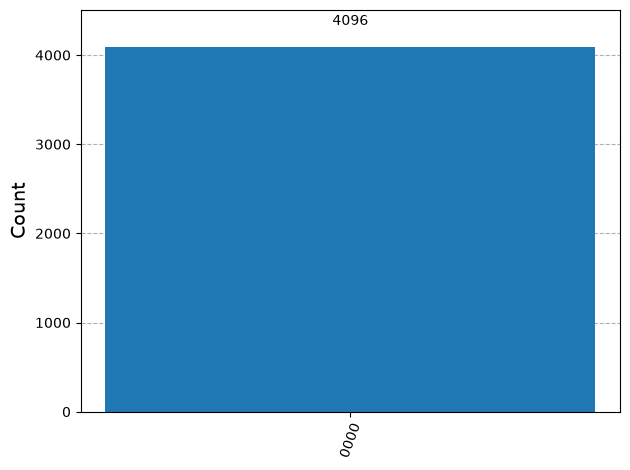

In [17]:
uniform_qft = QuantumCircuit(4)
for qubit in range(4):
    uniform_qft.h(qubit)
uniform_qft.append(QFTGate(4), range(4))

transpiled_uniform_qft = transpile(
    uniform_qft,
    basis_gates=["u", "cx"],
    optimization_level=0,
)

measured_uniform_qft = transpiled_uniform_qft.copy()
measured_uniform_qft.measure_all()

uniform_result = simulator.run(measured_uniform_qft, shots=shots).result()
uniform_counts = uniform_result.get_counts()

plot_histogram(uniform_counts)


### Interpretation

Die gleichmäßige Superposition ist der Fourier-Zustand zum Frequenzwert 0. Deshalb bildet die QFT den Zustand idealerweise auf `|0000>` ab. Im Histogramm sollte daher nahezu die gesamte Wahrscheinlichkeit bei `0000` liegen. Kleine Abweichungen entstehen nur durch die endliche Anzahl der Messungen (`shots`).
